# 3. Evaluation - Mixture of Experts


In [1]:
import os, numpy as np, pandas as pd, joblib, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

base_dir = os.path.join('..')
splits_dir = os.path.join(base_dir, 'data', 'splits')
models_dir = os.path.join(base_dir, 'models')

In [2]:
le = joblib.load(os.path.join(models_dir, 'label_encoder.pkl'))
selected_features = joblib.load(os.path.join(models_dir, 'selected_features.pkl'))
feature_sets = joblib.load(os.path.join(models_dir, 'expert_feature_sets.pkl'))
best_model_meta = joblib.load(os.path.join(models_dir, 'best_model_meta.pkl'))

stacking_base_models = joblib.load(os.path.join(models_dir, 'stacking_base_models.pkl'))
stacking_meta_model = joblib.load(os.path.join(models_dir, 'stacking_meta_model.pkl'))
stacking_schema = joblib.load(os.path.join(models_dir, 'stacking_schema.pkl'))

moe_expert1 = joblib.load(os.path.join(models_dir, 'moe_expert1_xgb.pkl'))
moe_expert2 = joblib.load(os.path.join(models_dir, 'moe_expert2_rf.pkl'))
moe_expert3 = joblib.load(os.path.join(models_dir, 'moe_expert3_et.pkl'))
moe_gate = joblib.load(os.path.join(models_dir, 'moe_gate_mlp.pkl'))

class_names = le.classes_.tolist()
num_classes = len(class_names)

test_df = pd.read_csv(os.path.join(splits_dir, 'test.csv'))
X_test = test_df[selected_features].values
y_test = test_df['label'].values.astype(int)

X1 = test_df[feature_sets['expert1']].values
X2 = test_df[feature_sets['expert2']].values
X3 = test_df[feature_sets['expert3']].values

print('Winner from training:', best_model_meta['winner_model'])
print('Loaded test data:', X_test.shape)

Winner from training: moe
Loaded test data: (82332, 30)


In [3]:
def metrics_dict(y_true, y_pred):
    return {
        'acc': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


def align_gate_probs(raw_probs, gate_classes, n_experts=3):
    out = np.zeros((raw_probs.shape[0], n_experts), dtype=np.float64)
    for i, cls in enumerate(gate_classes):
        out[:, int(cls)] = raw_probs[:, i]
    return out


def predict_stacking(X):
    blocks = [stacking_base_models[name].predict_proba(X) for name in stacking_schema['base_model_names']]
    meta_X = np.hstack(blocks)
    y_pred = stacking_meta_model.predict(meta_X)
    probs = stacking_meta_model.predict_proba(meta_X)
    return y_pred, probs


def predict_moe(X_full, X1, X2, X3):
    raw_gate = moe_gate.predict_proba(X_full)
    gate_probs = align_gate_probs(raw_gate, moe_gate.classes_, n_experts=3)

    p1 = moe_expert1.predict_proba(X1)
    p2 = moe_expert2.predict_proba(X2)
    p3 = moe_expert3.predict_proba(X3)

    probs = gate_probs[:, [0]] * p1 + gate_probs[:, [1]] * p2 + gate_probs[:, [2]] * p3
    y_pred = probs.argmax(axis=1)
    return y_pred, probs, gate_probs


y_pred_stack, probs_stack = predict_stacking(X_test)
y_pred_moe, probs_moe, gate_probs_moe = predict_moe(X_test, X1, X2, X3)

stack_metrics = metrics_dict(y_test, y_pred_stack)
moe_metrics = metrics_dict(y_test, y_pred_moe)

winner = best_model_meta['winner_model']
if winner == 'stacking':
    y_pred, probs = y_pred_stack, probs_stack
else:
    y_pred, probs = y_pred_moe, probs_moe

In [4]:
print('Stacking test metrics:', stack_metrics)
print('MoE test metrics     :', moe_metrics)
print('Winner model         :', winner)

print('\nWinner classification report')
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Stacking test metrics: {'acc': 0.7763081183500947, 'precision_macro': 0.558205995831529, 'recall_macro': 0.49368766188780605, 'f1_macro': 0.4937009475906072, 'f1_weighted': 0.795541540018674}
MoE test metrics     : {'acc': 0.738218432687169, 'precision_macro': 0.5369238296854605, 'recall_macro': 0.5734918154813772, 'f1_macro': 0.5130769562441486, 'f1_weighted': 0.7763053385384706}
Winner model         : moe

Winner classification report
                precision    recall  f1-score   support

      Analysis       0.04      0.12      0.06       677
      Backdoor       0.05      0.50      0.09       583
           DoS       0.37      0.15      0.22      4089
      Exploits       0.75      0.67      0.71     11132
       Fuzzers       0.29      0.61      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.97      0.74      0.84     37000
Reconnaissance       0.90      0.79      0.84      3496
     Shellcode       0.33      0.74      0.46       37

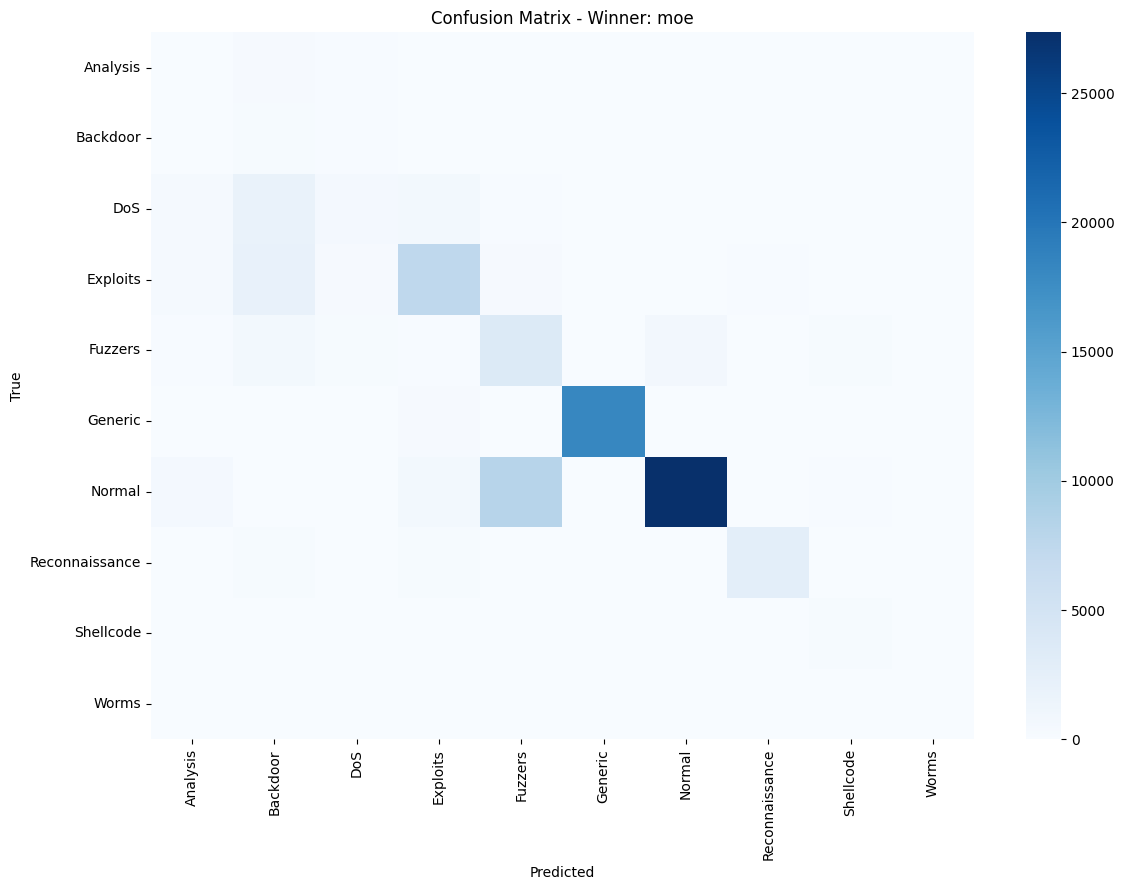

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Winner: {winner}')
plt.tight_layout()
plt.show()

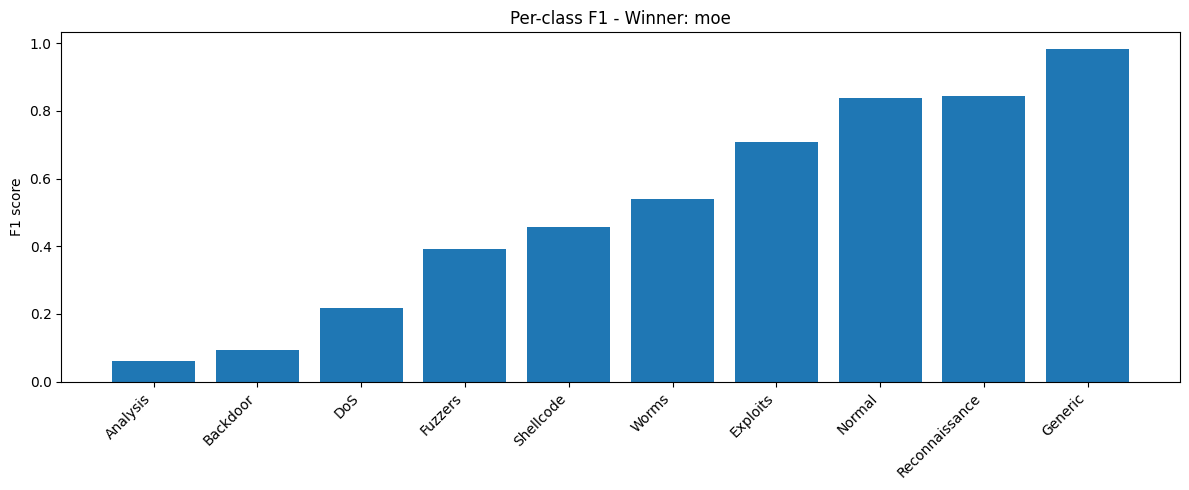

In [6]:
f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

plt.figure(figsize=(12, 5))
order = np.argsort(f1_per_class)
plt.bar(np.array(class_names)[order], f1_per_class[order])
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1 score')
plt.title(f'Per-class F1 - Winner: {winner}')
plt.tight_layout()
plt.show()

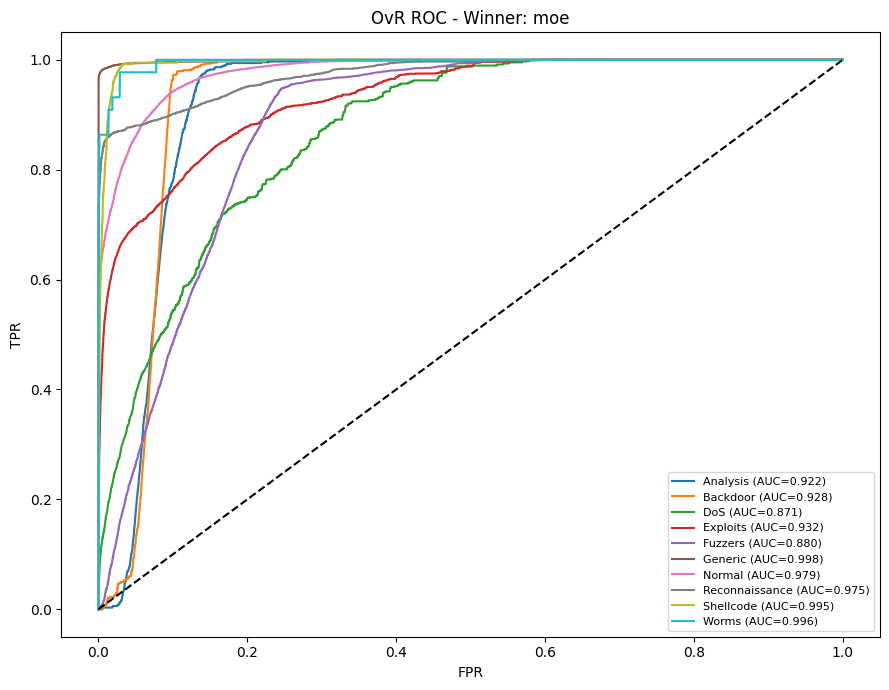

In [7]:
y_bin = label_binarize(y_test, classes=list(range(num_classes)))

plt.figure(figsize=(9, 7))
for i, cls in enumerate(class_names):
    if y_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'OvR ROC - Winner: {winner}')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

Binary (Normal vs Anomaly) metrics
Accuracy : 0.8710586406257591
Precision: 0.8213968300992446
Recall   : 0.978602311832701
F1       : 0.8931346889470505
              precision    recall  f1-score   support

      Normal       0.97      0.74      0.84     37000
     Anomaly       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332



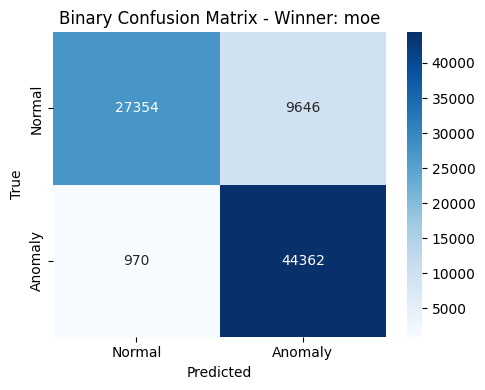

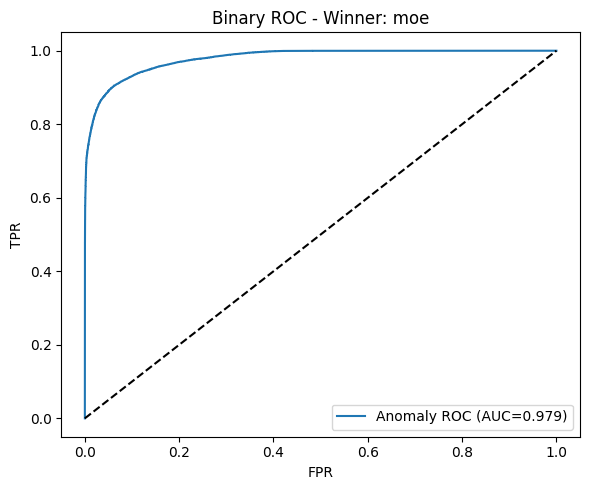

In [8]:
# Binary evaluation: Normal (0) vs Anomaly (1)
normal_candidates = [i for i, c in enumerate(class_names) if str(c).strip().lower() == 'normal']
if len(normal_candidates) == 0:
    raise ValueError("Could not find 'Normal' class in label encoder classes.")

normal_idx = normal_candidates[0]

y_test_bin = (y_test != normal_idx).astype(int)
y_pred_bin = (y_pred != normal_idx).astype(int)

acc_bin = accuracy_score(y_test_bin, y_pred_bin)
prec_bin = precision_score(y_test_bin, y_pred_bin, zero_division=0)
rec_bin = recall_score(y_test_bin, y_pred_bin, zero_division=0)
f1_bin = f1_score(y_test_bin, y_pred_bin, zero_division=0)

print('Binary (Normal vs Anomaly) metrics')
print('Accuracy :', acc_bin)
print('Precision:', prec_bin)
print('Recall   :', rec_bin)
print('F1       :', f1_bin)
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal', 'Anomaly'], zero_division=0))

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Binary Confusion Matrix - Winner: {winner}')
plt.tight_layout()
plt.show()

# Optional binary ROC using anomaly score = 1 - P(normal)
from sklearn.metrics import roc_auc_score
anomaly_score = 1.0 - probs[:, normal_idx]
auc_bin = roc_auc_score(y_test_bin, anomaly_score)
fpr_bin, tpr_bin, _ = roc_curve(y_test_bin, anomaly_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr_bin, tpr_bin, label=f'Anomaly ROC (AUC={auc_bin:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'Binary ROC - Winner: {winner}')
plt.legend()
plt.tight_layout()
plt.show()